In [289]:
import numpy as np
import glob
import os
from tqdm import tqdm  # For progress bar in notebook
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import cv2

In [290]:
# ============================================================================
# BASIC CALCULATIONS
# ============================================================================

def sum_of_squared_differences(matrix1, matrix2):
    """SSD between two matrices"""
    return np.sum(np.square(matrix1 - matrix2))

def sharpening_filter(identity_matrix, blur_matrix, alpha, blur_normalization=9):
    """Calculate sharpening filter: (1+a)*I - a*blur/normalization"""
    return (1 + alpha) * identity_matrix - (alpha / blur_normalization) * blur_matrix

def image_storage_bits(width, height, max_pixel_value):
    """Calculate bits needed to store image
    Args:
        width, height: image dimensions
        max_pixel_value: maximum pixel value (e.g., 1023 means 10 bits per pixel)
    """
    bits_per_pixel = int(max_pixel_value).bit_length()
    return width * height * bits_per_pixel

def initial_mean_shift_clusters(width, height):
    """Mean Shift starts with one cluster per pixel"""
    return width * height

# ============================================================================
# CAMERA GEOMETRY
# ============================================================================

def camera_intrinsic_matrix(fx, fy, cx, cy):
    """Create camera intrinsic matrix K"""
    return np.array([[fx, 0, cx],
                     [0, fy, cy],
                     [0, 0, 1]])

def world_to_pixel(K, world_point, R=None, t=None):
    """Project 3D world point to 2D pixel coordinates

    Args:
        K: 3x3 intrinsic matrix
        world_point: 3D point [x, y, z] or [x, y, z, 1]
        R: 3x3 rotation matrix (default: identity)
        t: 3x1 translation vector (default: zero)

    Returns:
        [u, v] pixel coordinates
    """
    if R is None:
        R = np.eye(3)
    if t is None:
        t = np.zeros((3, 1))

    # Convert to column vector and add homogeneous coordinate
    point = np.array(world_point).flatten()
    if len(point) == 3:
        point = np.append(point, 1)
    point = point.reshape(4, 1)

    # Create extrinsic matrix [R|t]
    extrinsic = np.hstack([R, t.reshape(3, 1)])

    # Project: pixel_h = K * [R|t] * world_h
    pixel_h = K @ extrinsic @ point

    # Normalize by homogeneous coordinate
    return (pixel_h[:2] / pixel_h[2]).flatten()

def camera_to_world(rvec, tvec, camera_point):
    """Transform point from camera to world coordinates (inverse PnP)

    Args:
        rvec: rotation vector [rx, ry, rz]
        tvec: translation vector [tx, ty, tz]
        camera_point: 3D point in camera coords [x, y, z]

    Returns:
        [x, y, z] in world coordinates
    """
    R = cv2.Rodrigues(np.array(rvec))[0]
    t = np.array(tvec).reshape(3, 1)
    p_cam = np.array(camera_point).reshape(3, 1)

    # P_world = R^T * (P_camera - t)
    return (R.T @ (p_cam - t)).flatten()

# ============================================================================
# TEMPLATE MATCHING
# ============================================================================

def sad_template_matching(measurements, template):
    """Find best matching subsequence using SAD

    Args:
        measurements: 1D array to search in
        template: 1D array pattern to find

    Returns:
        (best_match, sad_score, index)
    """
    measurements = np.array(measurements)
    template = np.array(template)
    template_len = len(template)

    best_sad = float('inf')
    best_match = None
    best_idx = -1

    for i in range(len(measurements) - template_len + 1):
        window = measurements[i:i+template_len]
        sad = np.sum(np.abs(window - template))

        if sad < best_sad:
            best_sad = sad
            best_match = window
            best_idx = i

    print(f"Best match: {best_match} at index {best_idx}")
    print(f"SAD score: {best_sad}")

    return best_match, best_sad, best_idx

# ============================================================================
# RANSAC
# ============================================================================

def ransac_iterations(success_prob, inlier_ratio, points_per_model):
    """Calculate RANSAC iterations: k = log(1-p) / log(1-w^s)

    Args:
        success_prob (p): desired probability (e.g., 0.98 for 98%)
        inlier_ratio (w): proportion of inliers (e.g., 0.75 for 75%)
        points_per_model (s): min points needed (e.g., 2 for line)
    """
    k = np.log(1 - success_prob) / np.log(1 - inlier_ratio**points_per_model)
    k = int(np.ceil(k))

    print(f"RANSAC iterations: {k}")
    print(f"(p={success_prob}, w={inlier_ratio}, s={points_per_model})")

    return k

# ============================================================================
# OPENCV VISION ALGORITHMS
# ============================================================================

def hough_lines(image_path, canny_low=100, canny_high=200,
                rho=1, theta=0.0017, threshold=200):
    """Detect lines using Hough transform"""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, canny_low, canny_high)
    lines = cv2.HoughLines(edges, rho, theta, threshold)

    num_lines = len(lines) if lines is not None else 0
    print(f"Lines detected: {num_lines}")

    return num_lines

def harris_corners(image_path, block_size=2, ksize=3, k=0.04, threshold=0.01):
    """Count Harris corners above threshold"""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)

    response = cv2.cornerHarris(gray, block_size, ksize, k)
    count = np.sum(response > threshold)

    print(f"Corners above {threshold}: {count}")

    return count

def optical_flow_max_displacement(img1_path, img2_path,
                                   max_corners=100, quality=0.3, min_dist=7):
    """Calculate max optical flow displacement in x direction"""
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    features = cv2.goodFeaturesToTrack(gray1, max_corners, quality, min_dist)
    new_features, status, _ = cv2.calcOpticalFlowPyrLK(gray1, gray2, features, None)

    good_old = features[status == 1]
    good_new = new_features[status == 1]

    max_x = np.max(np.abs(good_new[:, 0] - good_old[:, 0]))

    print(f"Max x displacement: {max_x:.2f}")

    return max_x

def average_epipolar_lines(left_img, right_img, num_matches=2000, ratio_test=0.75):
    """Calculate average epipolar lines from SIFT matches"""
    img_l = cv2.imread(left_img, 0)
    img_r = cv2.imread(right_img, 0)

    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img_l, None)
    kp2, des2 = sift.detectAndCompute(img_r, None)

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    # Ratio test
    good = [m for m, n in matches if m.distance < ratio_test * n.distance]
    good = sorted(good, key=lambda x: x.distance)[:num_matches]

    pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good])

    F, _ = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC)

    lines_l = cv2.computeCorrespondEpilines(pts2.reshape(-1, 1, 2), 2, F).reshape(-1, 3)
    lines_r = cv2.computeCorrespondEpilines(pts1.reshape(-1, 1, 2), 1, F).reshape(-1, 3)

    avg_l = np.mean(lines_l, axis=0)
    avg_r = np.mean(lines_r, axis=0)

    print(f"Avg epipolar (left):  {avg_l}")
    print(f"Avg epipolar (right): {avg_r}")

    return avg_l, avg_r

# ============================================================================
# MACHINE LEARNING
# ============================================================================

def elbow_method(data_path, k_min=2, k_max=8, plot=True):
    """K-means elbow method to find optimal clusters"""
    X = np.loadtxt(data_path)
    k_range = range(k_min, k_max)
    inertias = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42)
        km.fit(X)
        inertias.append(km.inertia_)
        print(f"k={k}: inertia={km.inertia_:.2f}")

    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(k_range, inertias, 'bx-', linewidth=2, markersize=10)
        plt.xlabel('k')
        plt.ylabel('Inertia')
        plt.title('Elbow Method')
        plt.grid(True)
        plt.show()

    return list(inertias)

def pca_components_for_variance(data_path, target_variance=0.95):
    """Find PCA components needed for target variance"""
    X = np.loadtxt(data_path)
    pca = PCA()
    pca.fit(X)

    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumvar >= target_variance) + 1

    print(f"Components for {target_variance*100:.0f}% variance: {n_components}")

    for i in range(min(10, len(cumvar))):
        print(f"  {i+1} components: {cumvar[i]*100:.2f}%")

    return n_components

def kmeans_on_pca(data_path, n_clusters, n_components):
    """Apply K-means on PCA-transformed data"""
    X = np.loadtxt(data_path)

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    km = KMeans(n_clusters=n_clusters, random_state=42)
    km.fit(X_pca)

    print(f"Inertia (k={n_clusters}, PCA={n_components}): {km.inertia_:.2f}")

    return km.inertia_

def linear_regression(x_path, y_path, plot=True):
    """Linear regression y = ax + b"""
    X = np.loadtxt(x_path).reshape(-1, 1)
    y = np.loadtxt(y_path)

    model = LinearRegression()
    model.fit(X, y)

    a = model.coef_[0]
    b = model.intercept_

    print(f"y = {a:.2f}x + {b:.2f}")

    if plot:
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, alpha=0.6, label='Data')
        plt.plot(X, model.predict(X), 'r-', linewidth=2,
                 label=f'y={a:.2f}x+{b:.2f}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend()
        plt.grid(True)
        plt.show()

    return a, b

def train_svm(data_path, test_ratio=0.30):
    """Train and test SVM (assumes last column is labels)"""
    data = np.loadtxt(data_path)
    X = data[:, :-1]
    y = data[:, -1]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=42
    )

    svm = SVC(kernel='linear', random_state=42)
    svm.fit(X_train, y_train)

    accuracy = accuracy_score(y_test, svm.predict(X_test))
    train_pct = (1 - test_ratio) * 100

    print(f"Training proportion: {train_pct:.0f}%")
    print(f"Accuracy: {accuracy:.2f}")

    return train_pct, accuracy

def train_svm(x_path, y_path, test_ratio=0.30):
    """Train and test SVM with separate feature and label files

    Args:
        x_path: path to features file (svm_x.txt)
        y_path: path to labels file (svm_y.txt)
        test_ratio: proportion for test set (default 0.30 = 30%)
    """
    X = np.loadtxt(x_path)
    y = np.loadtxt(y_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=42
    )

    svm = SVC(kernel='linear', random_state=42)
    svm.fit(X_train, y_train)

    accuracy = accuracy_score(y_test, svm.predict(X_test))
    train_pct = (1 - test_ratio) * 100

    print(f"Training proportion: {train_pct:.0f}%")
    print(f"Accuracy: {accuracy:.2f}")

    return train_pct, accuracy

# ============================================================================
# KALMAN FILTER
# ============================================================================

def kalman_predict(state, covariance, dt=1, process_noise=None):
    """Kalman prediction step (constant velocity model)

    Args:
        state: [x, x', y, y'] current state
        covariance: 4x4 current covariance matrix
        dt: time step
        process_noise: 4x4 Q matrix (default: zeros)
    """
    state = np.array(state).reshape(4, 1)
    P = np.array(covariance)

    # State transition (constant velocity)
    F = np.array([[1, dt, 0, 0],
                  [0, 1, 0, 0],
                  [0, 0, 1, dt],
                  [0, 0, 0, 1]])

    Q = np.zeros((4, 4)) if process_noise is None else process_noise

    x_pred = F @ state
    P_pred = F @ P @ F.T + Q

    print("Predicted state:")
    print(f"  x={x_pred[0,0]:.2f}, x'={x_pred[1,0]:.2f}")
    print(f"  y={x_pred[2,0]:.2f}, y'={x_pred[3,0]:.2f}")
    print("Predicted covariance:")
    print(P_pred)

    return x_pred.flatten(), P_pred

def kalman_update(state, covariance, measurement, measurement_noise):
    """Kalman update step (measures x and y position only)

    Args:
        state: [x, x', y, y'] predicted state
        covariance: 4x4 predicted covariance
        measurement: [x_measured, y_measured]
        measurement_noise: 2x2 R matrix
    """
    x = np.array(state).reshape(4, 1)
    P = np.array(covariance)
    z = np.array(measurement).reshape(2, 1)
    R = np.array(measurement_noise)

    # Observation matrix (measure position only)
    H = np.array([[1, 0, 0, 0],
                  [0, 0, 1, 0]])

    # Kalman gain
    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)

    # Update
    innovation = z - H @ x
    x_updated = x + K @ innovation
    P_updated = (np.eye(4) - K @ H) @ P

    print("Updated state:")
    print(f"  x={x_updated[0,0]:.6f}, x'={x_updated[1,0]:.6f}")
    print(f"  y={x_updated[2,0]:.6f}, y'={x_updated[3,0]:.6f}")

    return x_updated.flatten(), P_updated

def visual_odometry_stereo(left_folder, right_folder):
    """Visual Odometry using stereo images following the exam algorithm:

    Do only once:
    1.1. Capture two frames Ik-2, Ik-1
    1.2. Extract and match features between them
    1.3. Triangulate features from Ik-2, Ik-1

    Do at each iteration:
    2.1. Capture new frame Ik
    2.2. Extract features and match with previous frame Ik-1
    2.3. Compute camera pose (PnP) from 3D-to-2D matches
    2.4. Triangulate all new feature matches between Ik and Ik-1
    2.5. Iterate from 2.1
    """

    left_imgs = sorted(glob.glob(os.path.join(left_folder, '*.png')))
    right_imgs = sorted(glob.glob(os.path.join(right_folder, '*.png')))

    if len(left_imgs) == 0:
        print(f"No images found in {left_folder}")
        return None, None

    # Read first image to get dimensions
    img = cv2.imread(left_imgs[0])
    h, w = img.shape[:2]

    # KITTI camera parameters
    focal = 718.856
    cx = w / 2
    cy = h / 2
    baseline = 0.54  # 54cm baseline

    K = np.array([[focal, 0, cx],
                  [0, focal, cy],
                  [0, 0, 1]], dtype=np.float64)

    print(f"Image: {w}x{h}")
    print(f"Camera: f={focal:.1f}, c=({cx:.1f},{cy:.1f}), b={baseline}m")
    print(f"Processing {len(left_imgs)} frames...\n")

    # Feature detector
    sift = cv2.SIFT_create(nfeatures=3000)
    bf = cv2.BFMatcher(cv2.NORM_L2)

    def get_stereo_3d_points(img_l, img_r):
        """Get 3D points from stereo pair using SIFT matching"""
        kp_l, des_l = sift.detectAndCompute(img_l, None)
        kp_r, des_r = sift.detectAndCompute(img_r, None)

        if des_l is None or des_r is None:
            return np.array([]), np.array([]), None, None

        matches = bf.knnMatch(des_l, des_r, k=2)

        pts_3d = []
        pts_2d = []
        good_kp_indices = []

        for i, (m, n) in enumerate(matches):
            if m.distance < 0.75 * n.distance:
                pl = kp_l[m.queryIdx].pt
                pr = kp_r[m.trainIdx].pt
                disp = pl[0] - pr[0]

                if disp > 1.0:  # Minimum disparity
                    Z = focal * baseline / disp
                    if 0.5 < Z < 200:  # Valid depth range
                        X = (pl[0] - cx) * Z / focal
                        Y = (pl[1] - cy) * Z / focal
                        pts_3d.append([X, Y, Z])
                        pts_2d.append(pl)
                        good_kp_indices.append(m.queryIdx)

        return (np.array(pts_3d, dtype=np.float32),
                np.array(pts_2d, dtype=np.float32),
                kp_l, des_l)

    # ===== INITIALIZATION =====
    img_l0 = cv2.imread(left_imgs[0], 0)
    img_r0 = cv2.imread(right_imgs[0], 0)

    pts_3d, pts_2d, prev_kp, prev_des = get_stereo_3d_points(img_l0, img_r0)
    print(f"Initial triangulation: {len(pts_3d)} 3D points")

    if len(pts_3d) < 10:
        print("Not enough initial points!")
        return None, None

    # Cumulative pose - start at origin
    R_cumulative = np.eye(3)
    t_cumulative = np.zeros((3, 1))

    # ===== MAIN LOOP =====
    for i in tqdm(range(1, len(left_imgs)), desc="Processing frames"):
        curr_img_l = cv2.imread(left_imgs[i], 0)
        curr_img_r = cv2.imread(right_imgs[i], 0)

        # Detect features in current frame
        curr_kp, curr_des = sift.detectAndCompute(curr_img_l, None)

        if curr_des is None or prev_des is None or len(pts_3d) < 6:
            # Re-triangulate
            pts_3d, pts_2d, prev_kp, prev_des = get_stereo_3d_points(curr_img_l, curr_img_r)
            continue

        # Match previous to current
        matches = bf.knnMatch(prev_des, curr_des, k=2)

        # Build 3D-2D correspondences
        obj_pts = []
        img_pts = []

        # Create lookup for previous 2D points
        prev_pt_dict = {}
        for j, pt in enumerate(pts_2d):
            key = (int(pt[0]), int(pt[1]))
            prev_pt_dict[key] = j

        for m, n in matches:
            if m.distance < 0.75 * n.distance:
                prev_pt = prev_kp[m.queryIdx].pt
                key = (int(prev_pt[0]), int(prev_pt[1]))

                # Check neighborhood for matching 3D point
                for dx in range(-3, 4):
                    for dy in range(-3, 4):
                        check_key = (key[0] + dx, key[1] + dy)
                        if check_key in prev_pt_dict:
                            idx = prev_pt_dict[check_key]
                            obj_pts.append(pts_3d[idx])
                            img_pts.append(curr_kp[m.trainIdx].pt)
                            break
                    else:
                        continue
                    break

        if len(obj_pts) < 6:
            pts_3d, pts_2d, prev_kp, prev_des = get_stereo_3d_points(curr_img_l, curr_img_r)
            continue

        obj_pts = np.array(obj_pts, dtype=np.float32)
        img_pts = np.array(img_pts, dtype=np.float32)

        # Solve PnP
        success, rvec, tvec, inliers = cv2.solvePnPRansac(
            obj_pts, img_pts, K, None,
            iterationsCount=500,
            reprojectionError=2.0,
            flags=cv2.SOLVEPNP_ITERATIVE
        )

        if not success or inliers is None or len(inliers) < 6:
            pts_3d, pts_2d, prev_kp, prev_des = get_stereo_3d_points(curr_img_l, curr_img_r)
            continue

        # Get rotation matrix
        R, _ = cv2.Rodrigues(rvec)
        t = tvec.reshape(3, 1)

        # Accumulate pose: T_cumulative = T_new * T_cumulative
        # This gives us the camera pose in world coordinates
        t_cumulative = t_cumulative + R_cumulative @ t
        R_cumulative = R @ R_cumulative

        # Triangulate new 3D points for next iteration
        pts_3d, pts_2d, prev_kp, prev_des = get_stereo_3d_points(curr_img_l, curr_img_r)

    # Final camera position: C = -R^T * t
    camera_position = -R_cumulative.T @ t_cumulative
    rvec_final, _ = cv2.Rodrigues(R_cumulative)

    print("\n" + "="*50)
    print("FINAL POSE")
    print("="*50)
    print(f"Position:    [{camera_position[0,0]:7.3f}, {camera_position[1,0]:7.3f}, {camera_position[2,0]:7.3f}]")
    print(f"Orientation: [{rvec_final[0,0]:7.3f}, {rvec_final[1,0]:7.3f}, {rvec_final[2,0]:7.3f}]")

    print("\nExam format comparison:")
    print(f"Position = [{camera_position[0,0]:.3f}] [{camera_position[1,0]:.3f}] [{camera_position[2,0]:.3f}]")
    print(f"Rotation = [{rvec_final[0,0]:.3f}] [{rvec_final[1,0]:.3f}] [{rvec_final[2,0]:.3f}]")

    # Compare with exam options
    print("\nCompare with exam options:")
    options = [
        ([-11.908, 0.984, 1.727], [0.000, 1.296, 0.002]),
        ([-16.908, 0.684, 11.727], [0.0102, 1.596, 0.072]),
        ([-6.908, 0.384, 4.727], [0.040, 1.396, 0.271]),
        ([-7.908, 0.184, 7.727], [0.040, 1.996, 0.471])
    ]

    my_pos = camera_position.flatten()
    my_rot = rvec_final.flatten()

    for i, (pos, rot) in enumerate(options):
        pos_diff = np.linalg.norm(my_pos - np.array(pos))
        rot_diff = np.linalg.norm(my_rot - np.array(rot))
        print(f"  Option {i+1}: pos_diff={pos_diff:.2f}, rot_diff={rot_diff:.2f}")

    return camera_position.flatten(), rvec_final.flatten()

In [291]:
SSD1 = np.matrix([[10,15,20],
                    [20,20,25],
                    [10,15,20]])
SSD2 = np.matrix([[15,15,15],
                    [20,20,20],
                    [30,30,30]])

print(sum_of_squared_differences(SSD1,SSD2))

800


In [292]:
matrix1 = np.matrix([[0,0,0],[0,1,0],[0,0,0]])
matrix2 = np.ones((3,3))


print(sharpening_filter(matrix1, matrix2, 0.9))

[[-0.1 -0.1 -0.1]
 [-0.1  1.8 -0.1]
 [-0.1 -0.1 -0.1]]


In [293]:
print(image_storage_bits(120, 100, 1023))  # 120x100 image, 0-1023 values

120000


In [294]:
# Create intrinsic matrix
K = camera_intrinsic_matrix(fx=725, fy=726, cx=631, cy=360)

# Your 3D world point
world_point = [1, 1, 5]  # or np.array([1, 1, 5])

# Project world point to pixel coordinates
pixel_coords = world_to_pixel(K, world_point)
print(f"Pixel coordinates: {pixel_coords}")

Pixel coordinates: [776.  505.2]


In [295]:
height = 480
width = 640
initial_clusters = initial_mean_shift_clusters(height, width)
print(f"Initial clusters: {initial_clusters}")

Initial clusters: 307200


k=2: inertia=16118.81
k=3: inertia=9624.52
k=4: inertia=6010.10
k=5: inertia=3223.85
k=6: inertia=3101.24
k=7: inertia=2986.64


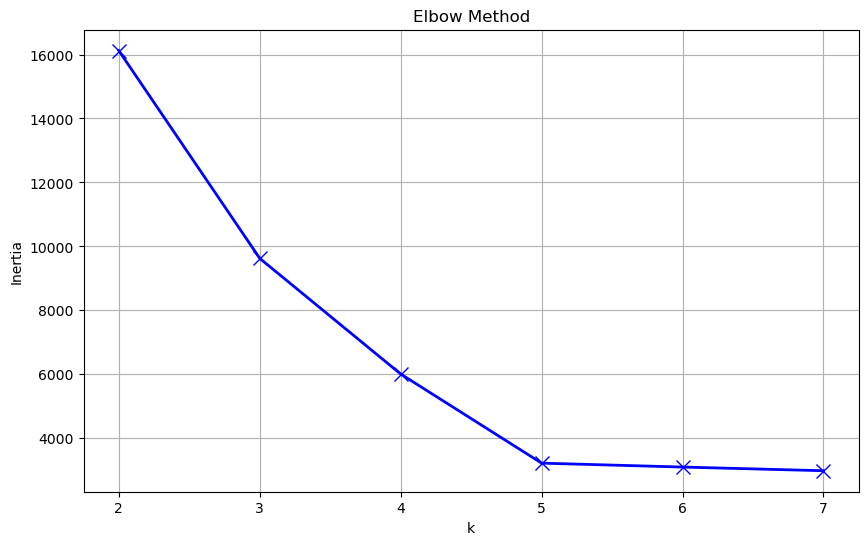

In [296]:
file_path = 'clusters.txt'  # or whatever your file path is
inertias = elbow_method(file_path, k_min=2, k_max=8, plot=True)

y = 0.55x + 19.86


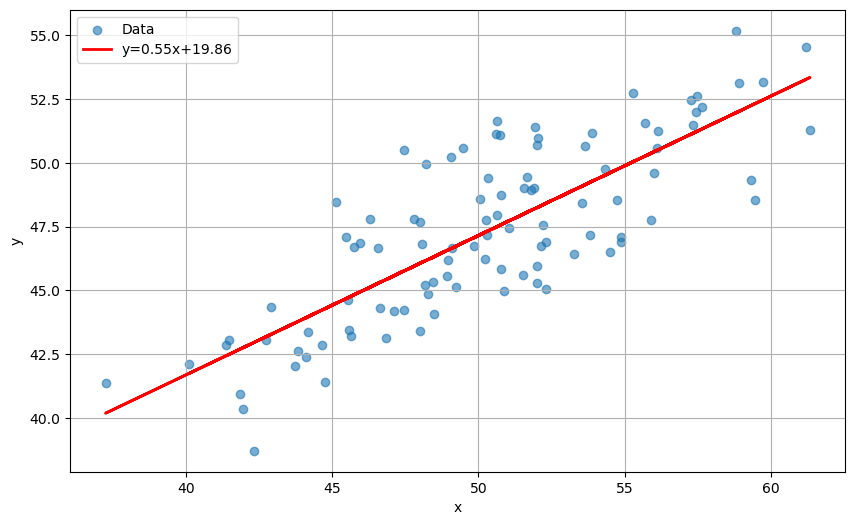

In [297]:
a, b = linear_regression('linear_reg_1.txt', 'linear_reg_2.txt', True)

In [298]:
# Your values
rvec = [-0.05, -1.51, -0.00]
tvec = [87.39, -2.25, -24.89]
point_camera = [-6.71, 0.23, 21.59]

# Calculate world coordinates
point_world = camera_to_world(rvec, tvec, point_camera)

print(f"World coordinates: X={point_world[0]:.2f}, Y={point_world[1]:.2f}, Z={point_world[2]:.2f}")
print(f"Answer: {point_world[0]:.2f}, {point_world[1]:.2f}, {point_world[2]:.2f}")


World coordinates: X=40.71, Y=-1.98, Z=96.75
Answer: 40.71, -1.98, 96.75


In [299]:
# Example: SAD matching
measurements = [47, 211, 38, 53, 204, 116, 152, 249, 143, 177]
template = [39, 55, 207]
sad_template_matching(measurements, template)

Best match: [ 38  53 204] at index 2
SAD score: 6


(array([ 38,  53, 204]), np.int64(6), 2)

In [300]:
# Example: RANSAC
ransac_iterations(success_prob=0.98, inlier_ratio=0.75, points_per_model=2)

RANSAC iterations: 5
(p=0.98, w=0.75, s=2)


5

In [301]:
# Example: Kalman prediction
state = [3, 0.5, 2, 0.33]
cov = [[5, 1, 0, 0],
       [1, 2, 0, 0],
       [0, 0, 5, 1],
       [0, 0, 1, 2]]
kalman_predict(state, cov, dt=1)

Predicted state:
  x=3.50, x'=0.50
  y=2.33, y'=0.33
Predicted covariance:
[[9. 3. 0. 0.]
 [3. 2. 0. 0.]
 [0. 0. 9. 3.]
 [0. 0. 3. 2.]]


(array([3.5 , 0.5 , 2.33, 0.33]),
 array([[9., 3., 0., 0.],
        [3., 2., 0., 0.],
        [0., 0., 9., 3.],
        [0., 0., 3., 2.]]))

In [302]:
# Example: Kalman update
pred_state = [5, 0.5, 7, 0.8]
pred_cov = [[0.2, 0, 0, 0],
            [0, 0.2, 0.1, 0],
            [0, 0, 0.2, 0],
            [0, 0, 0, 0.2]]
measurement = [4.8, 7.1]
R = [[0.2, 0.2],
     [0.2, 0.2]]
kalman_update(pred_state, pred_cov, measurement, R)

Updated state:
  x=4.833333, x'=0.566667
  y=7.133333, y'=0.800000


(array([4.83333333, 0.56666667, 7.13333333, 0.8       ]),
 array([[0.06666667, 0.        , 0.06666667, 0.        ],
        [0.03333333, 0.2       , 0.03333333, 0.        ],
        [0.06666667, 0.        , 0.06666667, 0.        ],
        [0.        , 0.        , 0.        , 0.2       ]]))

In [303]:
average_epipolar_lines('exam_files/Question_18/left.png', 'exam_files/Question_18/right.png')

Avg epipolar (left):  [-2.6310846e-02  9.9883616e-01 -1.5551392e+02]
Avg epipolar (right): [ 2.7464215e-02 -9.9875724e-01  1.5665720e+02]


(array([-2.6310846e-02,  9.9883616e-01, -1.5551392e+02], dtype=float32),
 array([ 2.7464215e-02, -9.9875724e-01,  1.5665720e+02], dtype=float32))

In [304]:
hough_lines('exam_files/Question_09/books.png')

Lines detected: 32


32

In [305]:
harris_corners('exam_files/Question_10/books.png')

Corners above 0.01: 499907


np.int64(499907)

In [306]:
optical_flow_max_displacement('exam_files/Question_11/things1.png', 'exam_files/Question_11/things2.png')

Max x displacement: 15.64


np.float32(15.636841)

y = 0.55x + 19.86


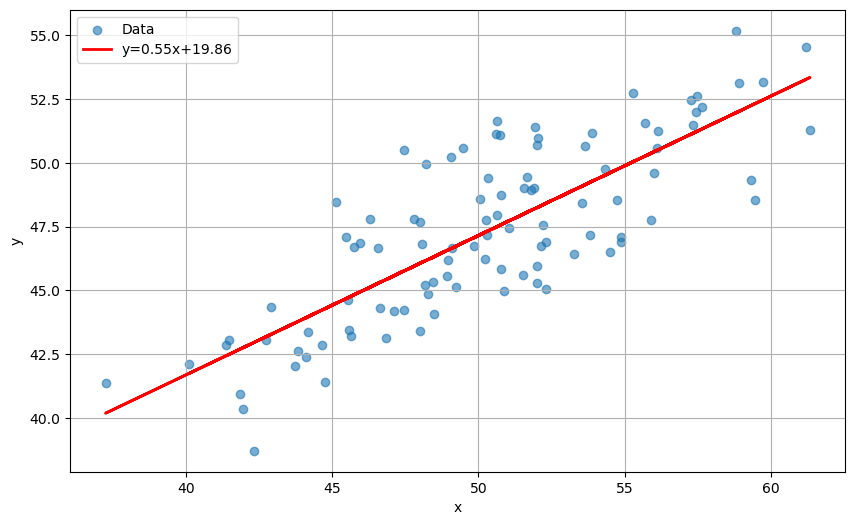

(np.float64(0.5458793766027309), np.float64(19.856337311955023))

In [307]:
linear_regression('exam_files/Question_24/lr_x.txt', 'exam_files/Question_24/lr_y.txt')

k=2: inertia=16118.81
k=3: inertia=9624.52
k=4: inertia=6010.10
k=5: inertia=3223.85
k=6: inertia=3101.24
k=7: inertia=2986.64


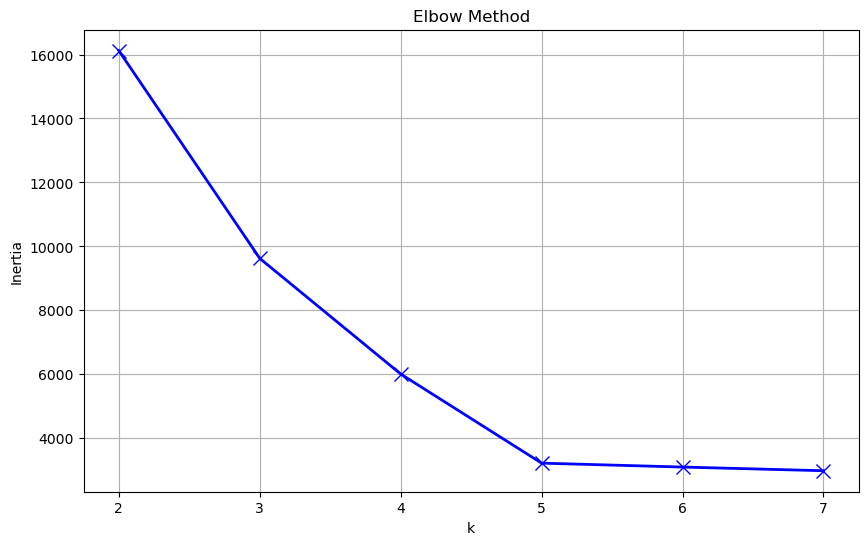

[16118.8125,
 9624.525,
 6010.1,
 3223.8500000000004,
 3101.244949494949,
 2986.6389055389054]

In [308]:
elbow_method("exam_files/Question_23/clusters.txt", k_min=2, k_max=8, plot=True)

In [309]:
pca_components_for_variance("exam_files/Question_23/clusters.txt", target_variance=0.95)

Components for 95% variance: 6
  1 components: 39.54%
  2 components: 67.31%
  3 components: 83.56%
  4 components: 91.59%
  5 components: 93.66%
  6 components: 95.48%
  7 components: 97.03%
  8 components: 98.21%
  9 components: 99.21%
  10 components: 100.00%


np.int64(6)

In [310]:
train_svm("exam_files/Question_29/svm_x.txt", "exam_files/Question_29/svm_y.txt")

Training proportion: 70%
Accuracy: 0.94


(70.0, 0.935672514619883)

In [311]:
visual_odometry_stereo("exam_files/Question_32/left", 'exam_files/Question_32/right')

Image: 1241x376
Camera: f=718.9, c=(620.5,188.0), b=0.54m
Processing 51 frames...

Initial triangulation: 359 3D points


Processing frames: 100%|██████████| 50/50 [00:05<00:00,  8.34it/s]


FINAL POSE
Position:    [-15.026,   0.380,  15.066]
Orientation: [  0.016,   1.594,   0.068]

Exam format comparison:
Position = [-15.026] [0.380] [15.066]
Rotation = [0.016] [1.594] [0.068]

Compare with exam options:
  Option 1: pos_diff=13.71, rot_diff=0.31
  Option 2: pos_diff=3.84, rot_diff=0.01
  Option 3: pos_diff=13.15, rot_diff=0.28
  Option 4: pos_diff=10.23, rot_diff=0.57


(array([-15.02632572,   0.37998348,  15.06605611]),
 array([0.01623566, 1.59387736, 0.06787246]))

In [312]:
def visual_odometry_by_pseudocode(left_folder, right_folder):
    """Literally follow the exam pseudocode"""

    # Get images
    left_imgs = sorted(glob.glob(f'{left_folder}/*.png'))
    right_imgs = sorted(glob.glob(f'{right_folder}/*.png'))

    # Reasonable defaults for autonomous vehicle stereo
    img = cv2.imread(left_imgs[0])
    h, w = img.shape[:2]

    focal = 721.5377  # KITTI-like
    cx = w / 2
    cy = h / 2
    baseline = 0.5396  # KITTI baseline in meters

    K = np.array([[focal, 0, cx],
                  [0, focal, cy],
                  [0, 0, 1]], dtype=np.float64)

    print(f"Using: f={focal}, c=({cx},{cy}), baseline={baseline}m")

    # Feature detector
    sift = cv2.SIFT_create()

    # ===== DO ONLY ONCE =====
    print("\n=== Initialization ===")

    # 1.1 Capture two frames I, I (left_0 and right_0)
    I_left_0 = cv2.imread(left_imgs[0], 0)
    I_right_0 = cv2.imread(right_imgs[0], 0)

    # 1.2 Extract and match features between them
    kp_l, des_l = sift.detectAndCompute(I_left_0, None)
    kp_r, des_r = sift.detectAndCompute(I_right_0, None)

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des_l, des_r, k=2)
    good = [m for m, n in matches if m.distance < 0.7 * n.distance]

    # 1.3 Triangulate features
    pts_l = np.float32([kp_l[m.queryIdx].pt for m in good])
    pts_r = np.float32([kp_r[m.trainIdx].pt for m in good])

    # Triangulate to 3D
    points_3d = []
    points_2d_prev = []
    descriptors_prev = []

    for i, (pl, pr) in enumerate(zip(pts_l, pts_r)):
        disp = pl[0] - pr[0]
        if disp > 1:
            Z = focal * baseline / disp
            if 0.1 < Z < 100:  # Valid depth
                X = (pl[0] - cx) * Z / focal
                Y = (pl[1] - cy) * Z / focal
                points_3d.append([X, Y, Z])
                points_2d_prev.append(pl)
                descriptors_prev.append(des_l[good[i].queryIdx])

    points_3d = np.array(points_3d, dtype=np.float64)
    descriptors_prev = np.array(descriptors_prev)

    print(f"Triangulated {len(points_3d)} points")

    # Initialize pose (world coordinate system)
    R_total = np.eye(3, dtype=np.float64)
    t_total = np.zeros((3, 1), dtype=np.float64)

    # ===== DO AT EACH ITERATION =====
    for idx in tqdm(range(1, len(left_imgs)), desc="Tracking"):

        # 2.1 Capture new frame I_k
        I_k_left = cv2.imread(left_imgs[idx], 0)
        I_k_right = cv2.imread(right_imgs[idx], 0)

        # 2.2 Extract features and match with previous frame
        kp_k, des_k = sift.detectAndCompute(I_k_left, None)

        matches_temp = bf.knnMatch(descriptors_prev, des_k, k=2)
        good_temp = [m for m, n in matches_temp if m.distance < 0.7 * n.distance]

        if len(good_temp) < 10:
            continue

        # Get 3D-2D correspondences
        obj_points = []
        img_points = []

        for m in good_temp:
            if m.queryIdx < len(points_3d):
                obj_points.append(points_3d[m.queryIdx])
                img_points.append(kp_k[m.trainIdx].pt)

        if len(obj_points) < 10:
            continue

        obj_points = np.array(obj_points, dtype=np.float64)
        img_points = np.array(img_points, dtype=np.float64)

        # 2.3 Compute camera pose (PnP) from 3D-to-2D matches
        success, rvec, tvec, inliers = cv2.solvePnPRansac(
            obj_points, img_points, K, None,
            iterationsCount=100, reprojectionError=8.0, confidence=0.99
        )

        if not success or inliers is None or len(inliers) < 8:
            continue

        R, _ = cv2.Rodrigues(rvec)
        t = tvec

        # Update global pose
        t_total = t_total + R_total @ t
        R_total = R @ R_total

        # 2.4 Triangulate all new feature matches between I_k and I_k (stereo)
        kp_k_r, des_k_r = sift.detectAndCompute(I_k_right, None)

        matches_stereo = bf.knnMatch(des_k, des_k_r, k=2)
        good_stereo = [m for m, n in matches_stereo if m.distance < 0.7 * n.distance]

        new_3d = []
        new_des = []

        for m in good_stereo[:500]:  # Limit new points
            pl = kp_k[m.queryIdx].pt
            pr = kp_k_r[m.trainIdx].pt
            disp = pl[0] - pr[0]

            if disp > 1:
                Z = focal * baseline / disp
                if 0.1 < Z < 100:
                    X = (pl[0] - cx) * Z / focal
                    Y = (pl[1] - cy) * Z / focal
                    new_3d.append([X, Y, Z])
                    new_des.append(des_k[m.queryIdx])

        if len(new_3d) > 0:
            points_3d = np.vstack([points_3d, new_3d])
            descriptors_prev = np.vstack([descriptors_prev, new_des])

        # 2.5 Iterate (happens automatically in loop)

    # Final pose
    rvec_final = cv2.Rodrigues(R_total)[0].flatten()
    position = t_total.flatten()

    print("\n" + "="*50)
    print("FINAL POSE")
    print("="*50)
    print(f"Position:    [{position[0]:8.3f}, {position[1]:8.3f}, {position[2]:8.3f}]")
    print(f"Orientation: [{rvec_final[0]:8.3f}, {rvec_final[1]:8.3f}, {rvec_final[2]:8.3f}]")

    return position, rvec_final

In [313]:
visual_odometry_by_pseudocode("exam_files/Question_32/left", "exam_files/Question_32/right")

Using: f=721.5377, c=(620.5,188.0), baseline=0.5396m

=== Initialization ===
Triangulated 316 points


Tracking: 100%|██████████| 50/50 [00:05<00:00,  9.04it/s]


FINAL POSE
Position:    [  44.047,    9.625,  -29.729]
Orientation: [   0.150,   -1.881,   -0.015]


(array([ 44.04673602,   9.62489274, -29.72875049]),
 array([ 0.15001446, -1.88116473, -0.01537089]))

In [315]:
state = [5,0.5,7,0.8]
cov = [[0.2,0,0,0],
       [0.2,0.1,0,0],
       [0,0,0.2,0],
       [0,0,0.2,0.1]]
position = [4.8, 7.1]
noise = [[0.2, 0.2], [0.2, 0.2]]
kalman_update(state, cov, position, noise)

Updated state:
  x=4.833333, x'=0.333333
  y=7.133333, y'=0.933333


(array([4.83333333, 0.33333333, 7.13333333, 0.93333333]),
 array([[0.06666667, 0.        , 0.06666667, 0.        ],
        [0.06666667, 0.1       , 0.06666667, 0.        ],
        [0.06666667, 0.        , 0.06666667, 0.        ],
        [0.06666667, 0.        , 0.06666667, 0.1       ]]))